In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from collections import defaultdict
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 82.6MB/s] 


In [5]:
model = models.resnet50(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s] 


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [7]:
epochs = 3

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(train_loader))

Epoch: 1 Loss: 0.2910784312269038
Epoch: 3 Loss: 0.09166503163254665


In [8]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [9]:
fp32_accuracy = evaluate(model)
print("FP32 Accuracy:", fp32_accuracy)

FP32 Accuracy: 94.49


In [10]:
activation_scores = defaultdict(list)

def get_activation(name):

    def hook(model, input, output):

        act = output.detach().cpu()

        score = torch.mean(torch.abs(act), dim=[0,2,3])

        activation_scores[name].append(score)

    return hook

In [11]:
hooks = []

for name, layer in model.named_modules():

    if isinstance(layer, nn.Conv2d):

        hooks.append(layer.register_forward_hook(get_activation(name)))

In [12]:
model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        model(images)

In [13]:
for h in hooks:
    h.remove()

In [14]:
attention_scores = {}

for layer in activation_scores:

    scores = torch.stack(activation_scores[layer])

    attention_scores[layer] = torch.mean(scores, dim=0)

In [15]:
def quantize_tensor(tensor, bits):

    qmin = 0
    qmax = 2**bits - 1

    min_val = tensor.min()
    max_val = tensor.max()

    scale = (max_val - min_val) / (qmax - qmin + 1e-8)

    q_tensor = torch.round((tensor - min_val) / scale)

    q_tensor = torch.clamp(q_tensor, qmin, qmax)

    dequant = q_tensor * scale + min_val

    return dequant

In [16]:
for name, layer in model.named_modules():

    if isinstance(layer, nn.Conv2d):

        weights = layer.weight.data

        scores = attention_scores[name]

        mean = torch.mean(scores)
        std = torch.std(scores)

        for idx, score in enumerate(scores):

            if score > mean + std:
                bits = 8

            elif score >= mean:
                bits = 7

            else:
                bits = 6

            weights[idx] = quantize_tensor(weights[idx], bits)

In [17]:
daabq_accuracy = evaluate(model)

print("DAABQ Accuracy:", daabq_accuracy)

DAABQ Accuracy: 94.28


In [18]:
quantized_state_dict = {}

for name, param in model.state_dict().items():

    if "weight" in name:

        min_val = param.min()
        max_val = param.max()

        scale = (max_val - min_val) / 255

        q = torch.round((param - min_val) / scale).to(torch.uint8)

        quantized_state_dict[name] = q
        quantized_state_dict[name+"_scale"] = scale
        quantized_state_dict[name+"_min"] = min_val

    else:
        quantized_state_dict[name] = param

In [19]:
torch.save(quantized_state_dict, "daabq_model.pth")

size = os.path.getsize("daabq_model.pth")/(1024*1024)

print("DAABQ Model Size:", size, "MB")

DAABQ Model Size: 22.87524700164795 MB


In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[952   1   9   2   0   4   3   5  18   6]
 [ 11 956   1   0   0   0   1   2   2  27]
 [ 12   0 928  12  12  12  12  10   2   0]
 [  2   0  16 856   5  93   9  12   3   4]
 [  3   0  10  15 925  28   7  10   1   1]
 [  1   0   6  31   3 947   2   9   1   0]
 [  3   1   7  13   1  11 961   3   0   0]
 [  1   0   4   3   6  15   0 971   0   0]
 [ 22   6   3   0   0   0   1   1 964   3]
 [ 11  13   1   0   0   0   0   1   6 968]]


In [21]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [22]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# CIFAR-10 class names
classes = ['Airplane','Automobile','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']


def plot_confusion_matrix(model, dataloader, device, title):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

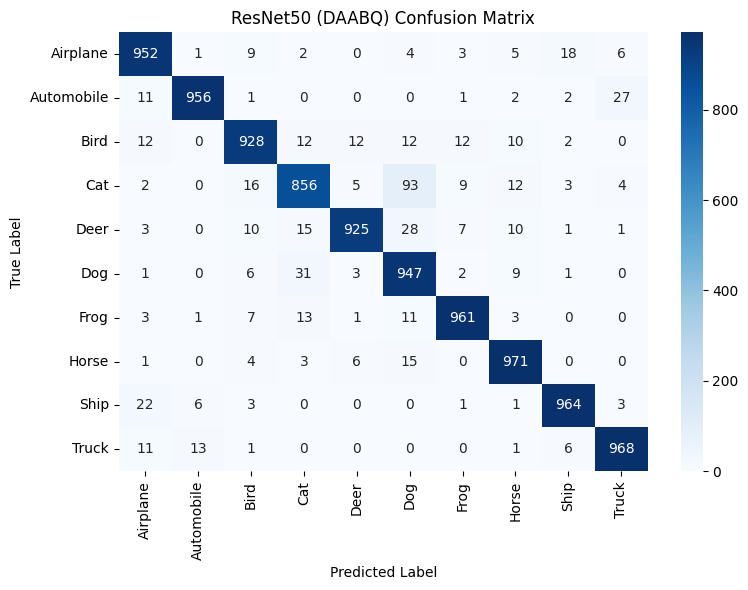

In [23]:
plot_confusion_matrix(model, test_loader, device,
                      "ResNet50 (DAABQ) Confusion Matrix")